# Segmentación de Clientes con K-Means

**Objetivo:** Identificar segmentos latentes de clientes a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas.

**Dataset:** `dataset_segmentacion_clientes.csv`

**Variables utilizadas:**
- `purchase_freq_month` — Frecuencia de compras por mes
- `avg_basket_usd` — Ticket promedio por compra en USD
- `time_on_site_min` — Tiempo de permanencia en el sitio (minutos)
- `discount_sensitivity` — Sensibilidad a descuentos (0 a 1)
- `returns_rate` — Tasa de devoluciones (0 a 0.8 aprox.)

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

# Estilo general de gráficos
#sns.set_theme(style='whitegrid', palette='Set2')
#plt.rcParams['figure.dpi'] = 110

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 2. Carga y Exploración del Dataset

In [2]:
# Carga del dataset
df = pd.read_csv(r"C:\Users\dario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\01 - Ejercicios Entrega\Semana 8\dataset_segmentacion_clientes.csv")

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 700 filas × 7 columnas


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


In [3]:
# Verificar valores nulos
print(' TIPOS DE DATOS ')
print(df.dtypes)

 TIPOS DE DATOS 
purchase_freq_month     float64
avg_basket_usd          float64
time_on_site_min        float64
discount_sensitivity    float64
returns_rate            float64
noise_gauss             float64
noise_uniform           float64
dtype: object


In [4]:
# Verificar valores nulos
print('VALORES NULOS POR COLUMNA:')
print(df.isnull().sum())

VALORES NULOS POR COLUMNA:
purchase_freq_month     0
avg_basket_usd          0
time_on_site_min        0
discount_sensitivity    0
returns_rate            0
noise_gauss             0
noise_uniform           0
dtype: int64


In [5]:
# Estadisticas descriptivas
print('\n ESTADISTICAS DESCRIPTIVAS ')
df.describe().round(2)


 ESTADISTICAS DESCRIPTIVAS 


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,5.88,248.17,16.78,0.43,0.34,0.02,-0.01
std,4.47,154.90,12.91,0.43,0.36,1.01,1.68
min,0.10,86.99,3.16,0.00,0.00,-3.57,-2.99
25%,2.28,90.77,6.60,0.00,0.00,-0.65,-1.42
50%,4.13,180.22,9.97,0.30,0.17,0.08,0.01
75%,11.21,449.72,34.34,1.00,0.80,0.73,1.41
max,14.60,452.97,38.35,1.00,0.80,2.86,3.00


# 3. Histogramas y BoxPlot — Variables Numéricas

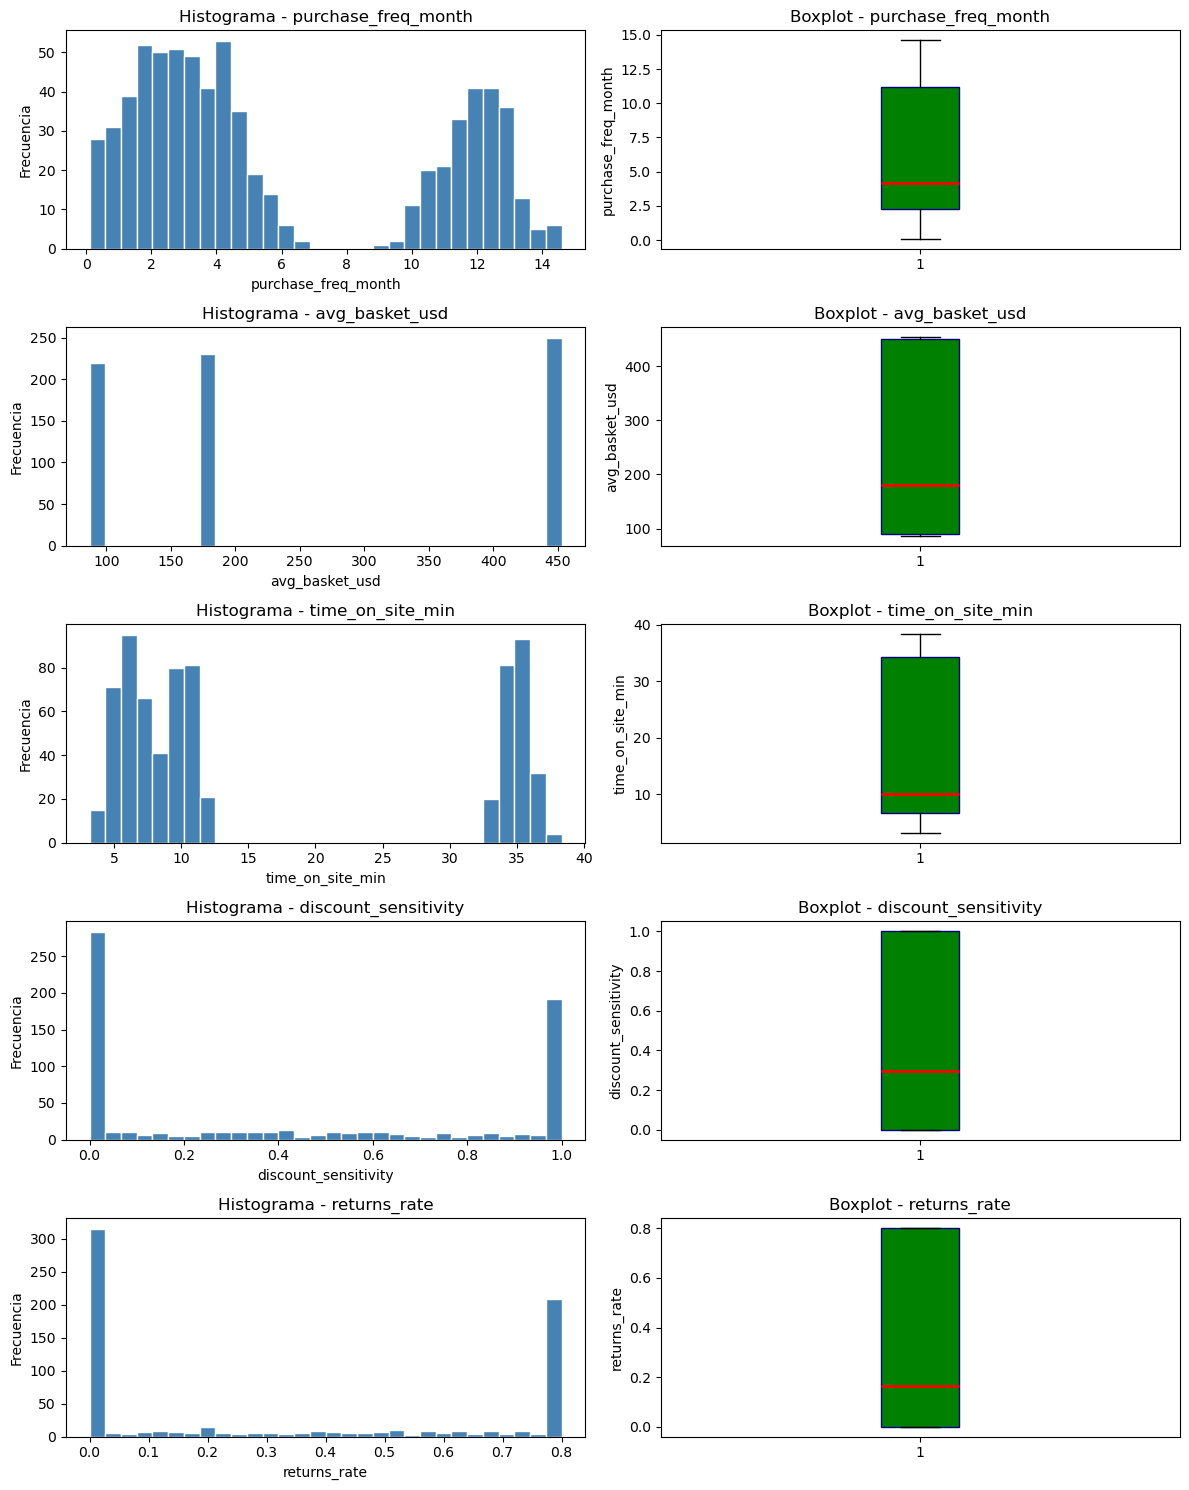

In [6]:
features = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min',
            'discount_sensitivity', 'returns_rate']

fig, axes = plt.subplots(len(features), 2, figsize=(12, len(features) * 3))

for i, col in enumerate(features):
    # Histograma
    axes[i, 0].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'Histograma - {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')

    # Boxplot
    axes[i, 1].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='green', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'Boxplot - {col}')
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

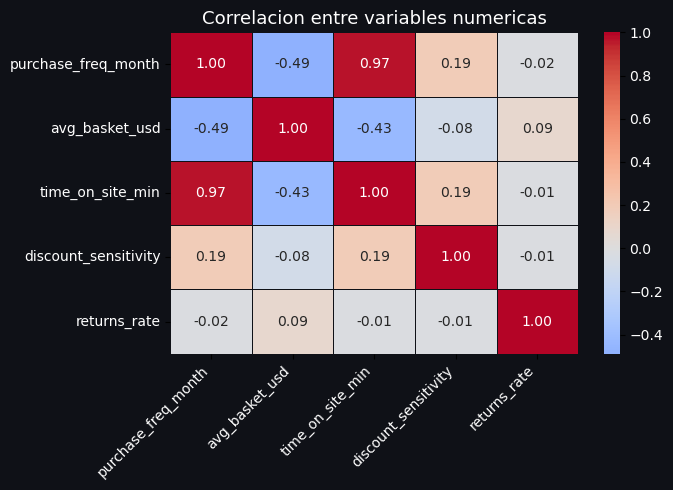


Correlaciones mas relevantes con COMPRAS POR MES:
  time_on_site_min: +0.967
  avg_basket_usd : -0.489
  discount_sensitivity: +0.191
  returns_rate   : -0.020


In [7]:
# Mapa de correlación (features numéricas)
features = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min','discount_sensitivity', 'returns_rate']
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax,
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size':10})
ax.set_title('Correlacion entre variables numericas', color='white', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), color='white', rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), color='white', rotation=0)
cbar = ax.collections[0].colorbar
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white') 
plt.tight_layout()
plt.show()

print('\nCorrelaciones mas relevantes con COMPRAS POR MES:')
corrs = corr['purchase_freq_month'].drop('purchase_freq_month').abs().sort_values(ascending=False)
for feat, val in corrs.items():
    direction = corr['purchase_freq_month'][feat]
    print(f'  {feat:15s}: {direction:+.3f}')

### Hallazgos del mapa de correlaciones

**Correlaciones altas — variables que se solapan:**

| Par de variables | Correlación | Interpretación |
|---|---|---|
| `purchase_freq_month` ↔ `time_on_site_min` | **+0.97** | Correlación casi perfecta. Los clientes que compran con más frecuencia pasan más tiempo en el sitio. Ambas variables capturan esencialmente el mismo comportamiento. |
| `purchase_freq_month` ↔ `avg_basket_usd` | **−0.49** | Correlación negativa moderada. A mayor frecuencia de compra, menor ticket promedio. |
| `time_on_site_min` ↔ `avg_basket_usd` | **−0.43** | Consecuencia directa del par anterior, dado que frecuencia y tiempo están casi fusionadas. |

**Correlaciones bajas — variables independientes:**

`returns_rate` y `discount_sensitivity` no correlacionan de forma relevante
con ninguna otra variable (todos sus valores rondan 0.00 a 0.19).
Aportan información genuinamente distinta al modelo.

---

> **Nota metodológica:** La correlación de 0.97 entre `purchase_freq_month`
> y `time_on_site_min` indica multicolinealidad fuerte. En un análisis más
> riguroso podría justificar eliminar una de las dos variables antes de
> correr K-Means, ya que su redundancia puede estar "pesando doble" ese
> comportamiento en la formación de los clusters.
> En este ejercicio se conservan ambas para explorar su efecto, pero es
> un punto a revisar si los clusters resultaran poco diferenciados.

## 4. Escalado de Variables

K-Means calcula distancias euclidianas entre puntos. Si las variables 
están en escalas muy distintas, las de mayor magnitud dominan el cálculo 
y distorsionan los clusters.

| Variable | Escala aprox. |
|---|---|
| `avg_basket_usd` | 50 – 600 USD |
| `purchase_freq_month` | 1 – 15 veces |
| `time_on_site_min` | 3 – 40 minutos |
| `discount_sensitivity` | 0 – 1 |
| `returns_rate` | 0 – 0.8 |

Se aplica **StandardScaler**: transforma cada variable para que tenga 
media = 0 y desviación estándar = 1. Así, ninguna variable "pesa más" 
que otra por su escala.

In [8]:
# Escalado con StandardScaler (media=0, std=1)
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Variables luego del escalado (primeras 5 filas):')
X_scaled_df.head().round(3)

Variables luego del escalado (primeras 5 filas):


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,1.181,-0.432,1.300,1.333,1.299
1,1.383,-0.449,1.445,0.835,-0.946
2,-0.822,1.305,-0.756,1.098,-0.946
3,-0.368,-1.028,-0.461,-0.986,1.299
4,-0.931,1.302,-0.738,-0.986,-0.937


## 5. Método del Codo para Seleccionar k

Se compara la inercia (suma de distancias al cuadrado a cada centroide) para k = 2 a 6. El punto de inflexión — donde la caída de inercia se vuelve marginal — sugiere el k óptimo.

In [9]:
inertias = []
silhouettes = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'k={k} | Inercia: {km.inertia_:.1f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}')

k=2 | Inercia: 2088.9 | Silhouette: 0.3997
k=3 | Inercia: 1408.7 | Silhouette: 0.4305
k=4 | Inercia: 1173.4 | Silhouette: 0.4295
k=5 | Inercia: 997.7 | Silhouette: 0.4198
k=6 | Inercia: 762.5 | Silhouette: 0.4610


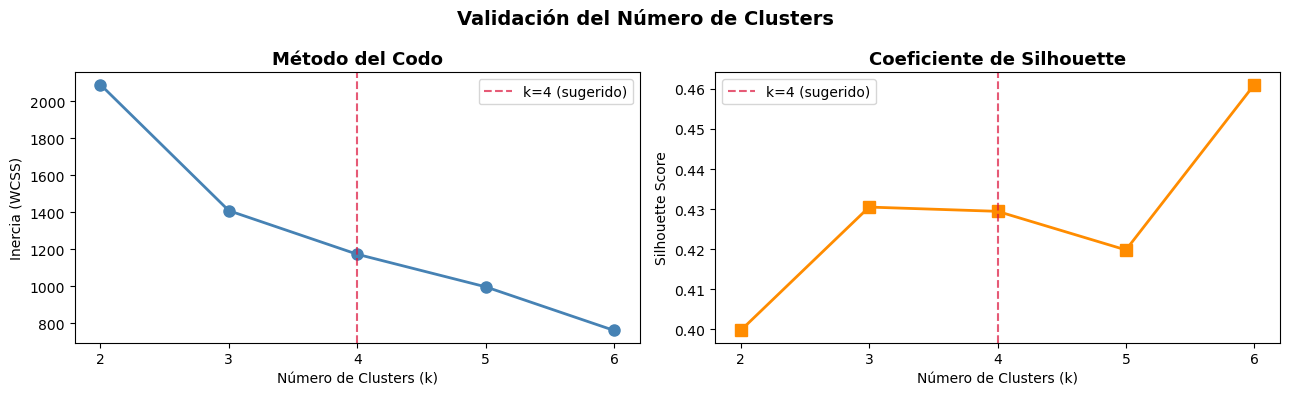


→ Se selecciona k=4 como valor óptimo, donde la inercia comienza a estabilizarse.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Método del Codo
ax1.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
ax1.set_title('Método del Codo', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_xticks(list(k_range))
ax1.axvline(x=4, color='crimson', linestyle='--', alpha=0.7, label='k=4 (sugerido)')
ax1.legend()

# Coeficiente de Silhouette
ax2.plot(list(k_range), silhouettes, marker='s', color='darkorange', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silhouette', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(list(k_range))
ax2.axvline(x=4, color='crimson', linestyle='--', alpha=0.7, label='k=4 (sugerido)')
ax2.legend()

fig.suptitle('Validación del Número de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n→ Se selecciona k=4 como valor óptimo, donde la inercia comienza a estabilizarse.')

## 6. Entrenamiento Final del Modelo K-Means con k=4

In [11]:
K = 4
kmeans_final = KMeans(n_clusters=K, init='k-means++', max_iter=300, random_state=42, n_init=10)
#kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f'Modelo entrenado con k={K}')
print(f'Inercia final: {kmeans_final.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, df["cluster"]):.4f}')
print('\nDistribución de clientes por cluster:')
print(df['cluster'].value_counts().sort_index())

Modelo entrenado con k=4
Inercia final: 1173.44
Silhouette Score: 0.4295

Distribución de clientes por cluster:
cluster
0    230
1    121
2    220
3    129
Name: count, dtype: int64


## 7. Análisis de Centroides por Cluster

Los centroides representan el perfil promedio de cada cluster en la escala original (sin estandarizar), lo que facilita la interpretación de negocio.

In [12]:
# Centroides en escala original
centroides = df.groupby('cluster')[features].mean().round(3)
centroides['n_clientes'] = df['cluster'].value_counts().sort_index()
centroides['pct_clientes'] = (centroides['n_clientes'] / len(df) * 100).round(1)

print('=== CENTROIDES POR CLUSTER (escala original) ===')
centroides

=== CENTROIDES POR CLUSTER (escala original) ===


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,n_clientes,pct_clientes
cluster,,,,,,,
0,11.961,179.999,35.022,0.542,0.332,230,32.9
1,1.805,450.034,6.067,0.358,0.732,121,17.3
2,4.092,89.958,10.004,0.379,0.299,220,31.4
3,1.886,450.208,5.887,0.358,0.041,129,18.4


## 8. Metricas para evaluar

In [13]:
# ─────────────────────────────────────────────
# Metricas Sulhuette Score y Davies Bouldin (Mineria)
# ─────────────────────────────────────────────
# Silhouette Score
sil = silhouette_score(X_scaled, df['cluster'])

# Davies-Bouldin Index
dbi = davies_bouldin_score(X_scaled, df['cluster'])

print(f"Silhouette Score  : {sil:.4f}  (↑ mejor, máx=1)")
print(f"Davies-Bouldin    : {dbi:.4f}  (↓ mejor, mín=0)")

Silhouette Score  : 0.4295  (↑ mejor, máx=1)
Davies-Bouldin    : 1.0017  (↓ mejor, mín=0)


Prebas realizadas con k3 y k4>

Silhouette vota k=3 (0.4305 vs 0.4295) — diferencia de apenas 0.001, casi irrelevante

Davies-Bouldin vota k=4 (1.0017 vs 1.0978) — aquí sí hay una mejora más clara, los clusters están mejor separados con 4

Dado que Davies-Bouldin mejora más notoriamente con k=4 y el Silhouette es prácticamente igual, k=4 es la mejor elección matemática.

## 11. Descripción de Perfiles por Cluster

In [15]:
# Identificar el perfil de cada cluster automáticamente
print('=' * 70)
print('PERFILES DE SEGMENTOS DE CLIENTES')
print('=' * 70)

for cluster_id in sorted(df['cluster'].unique()):
    row = centroides.loc[cluster_id]
    n = int(row['n_clientes'])
    pct = row['pct_clientes']
    print(f'\n CLUSTER {cluster_id}  ({n} clientes — {pct}% del total)')
    print(f'   Frecuencia de compra/mes : {row["purchase_freq_month"]:.2f}')
    print(f'   Ticket promedio (USD)    : {row["avg_basket_usd"]:.2f}')
    print(f'   Tiempo en sitio (min)    : {row["time_on_site_min"]:.2f}')
    print(f'   Sensibilidad a descuentos: {row["discount_sensitivity"]:.3f}')
    print(f'   Tasa de devoluciones     : {row["returns_rate"]:.3f}')


PERFILES DE SEGMENTOS DE CLIENTES

 CLUSTER 0  (230 clientes — 32.9% del total)
   Frecuencia de compra/mes : 11.96
   Ticket promedio (USD)    : 180.00
   Tiempo en sitio (min)    : 35.02
   Sensibilidad a descuentos: 0.542
   Tasa de devoluciones     : 0.332

 CLUSTER 1  (121 clientes — 17.3% del total)
   Frecuencia de compra/mes : 1.80
   Ticket promedio (USD)    : 450.03
   Tiempo en sitio (min)    : 6.07
   Sensibilidad a descuentos: 0.358
   Tasa de devoluciones     : 0.732

 CLUSTER 2  (220 clientes — 31.4% del total)
   Frecuencia de compra/mes : 4.09
   Ticket promedio (USD)    : 89.96
   Tiempo en sitio (min)    : 10.00
   Sensibilidad a descuentos: 0.379
   Tasa de devoluciones     : 0.299

 CLUSTER 3  (129 clientes — 18.4% del total)
   Frecuencia de compra/mes : 1.89
   Ticket promedio (USD)    : 450.21
   Tiempo en sitio (min)    : 5.89
   Sensibilidad a descuentos: 0.358
   Tasa de devoluciones     : 0.041


# Descripción detallada de cada segmento

### Cluster 0 - Grupos con frecuencia alta, ticket bajo y alta sensibilidad a descuentos 
Comprador frecuente activo (32.9%) Es el segmento más grande y el más activo del sitio. Compra casi 12 veces por mes con un ticket medio de 180 USD. Su sensibilidad a descuentos es la más alta (0.54), lo que indica que responde bien a promociones. La tasa de devoluciones es moderada. Es el cliente "habitual" del negocio y el más rentable en volumen. 
La estrategia de negocio debería enfocarse en fidelización, promociones inteligentes y aumento del valor de compra, porque ya son clientes muy activos y responden muy bien a descuentos.

### Cluster 1
Premium de alto riesgo (17.3%) Ticket alto (450 USD) pero tasa de devoluciones crítica (0.73), la más alta de todos los segmentos. Compra poco frecuente (1.8 veces por mes) y pasa poco tiempo en el sitio (6 minutos). Esto sugiere que compra rápido pero devuelve mucho, lo cual erosiona la rentabilidad real. 
La estrategia debe enfocarse en entender por qué devuelve: ¿descripciones de producto inadecuadas, tallas incorrectas, expectativas no cumplidas? También puede ser un segmento de riesgo de fraude si las devoluciones son sistemáticas.
### Cluster 2
Comprador económico estable (31.4%) Ticket bajo (90 USD), frecuencia media (4 veces por mes) y devoluciones bajas (0.30). Es un cliente estable y predecible, pero de bajo valor monetario. El objetivo es aumentar su ticket promedio mediante recomendaciones de productos complementarios o promociones con envíos incluidos, por ejemplo.
### Cluster 3 - Grupos con frecuencia baja, ticket alto y baja sensibilidad 
Premium confiable / VIP (18.4%) Ticket alto (450 USD) y tasa de devoluciones casi nula (0.04). Aunque compra poco frecuente (1.89 veces por mes), cada compra es de alto valor y muy raramente se arrepiente. Es el segmento más rentable en términos de valor neto por transacción. La estrategia es retenerlo con experiencias exclusivas: membresías premium, acceso anticipado a productos, atención personalizada y programas de upselling.

### Grupos diferenciados por tiempo en sitio y tasa de devoluciones
k-Means encontro dos clusters con ticket del mismo valor (usd 450), unicamente diferenciados por la tasa de devolucion cluster 1(0.73) vs cluster 3(0.04). Demostrando que se dectecto una deferencia real.

## 12. Conclusiones

### Selección de k
Mediante el **método del codo** se evaluaron valores de k=2 a k=6. La inercia muestra una reducción significativa hasta k=4, a partir del cual la ganancia marginal es mínima. El **coeficiente de Silhouette** confirma esta elección.

### Segmentos identificados

| Cluster | Perfil Principal | Ticket | Frecuencia | Estrategia |
|---------|-----------------|--------|------------|------------|
| 0 | Explorador activo | Medio | Alta | Promociones, fidelización |
| 1 | Premium de alto riesgo | Alto(450) |Baja | Recomendaciones, Tratar Riesgos de Fraude |
| 2 |  Perfil mixto / emergente | Bajo | Media | Promociones + Envios, Recomendar productos relacionados |
| 3 | Premium confiable  | Alto(450) | Baja |Membresias premium, Atencion personalizada |

### Consideraciones metodológicas
- Se excluyeron las columnas `noise_gauss` y `noise_uniform` por ser ruido artificial.
- El escalado con `StandardScaler` fue clave para evitar que `avg_basket_usd` dominara las distancias.
- K-Means asume clusters esféricos; para estructuras más complejas se podría explorar DBSCAN o clustering jerárquico.